<a href="https://colab.research.google.com/github/Saisuman55/todo-major-project/blob/main/Logistic_Regression_Major_Project_1_Sanskar_Bhosale.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
uploaded=files.upload()

Saving Logistic_Regression.xlsx to Logistic_Regression (3).xlsx


Importing Libraries

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [ ]:
import os
os.listdir()

['.config',
 'Logistic_Regression (1).xlsx',
 'Logistic_Regression (3).xlsx',
 'Logistic_Regression (2).xlsx',
 'Logistic_Regression.xlsx',
 'sample_data']

In [ ]:
df=pd.read_excel("Logistic_Regression (3).xlsx")

In [ ]:
df.head()

,UDI,Product ID,Type(Quality),Air temperature [K],Process temperature [K],Pressure(Pa),Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure
0,1,M14860,M,298.1,308.6,1000.695430,1551,42.8,0,0
1,2,L47181,L,298.2,308.7,992.757881,1408,46.3,3,0
2,3,L47182,L,298.1,308.5,1002.509288,1498,49.4,5,0
3,4,L47183,L,298.2,308.6,994.701873,1433,39.5,7,0
4,5,L47184,L,298.2,308.7,995.131057,1408,40.0,9,0


In [ ]:
df.tail()

,UDI,Product ID,Type(Quality),Air temperature [K],Process temperature [K],Pressure(Pa),Rotational speed [rpm],Torque [Nm],Tool wear [min]
9995,9996,M24855,M,298.8,308.4,NaN,1604,29.5,14
9996,9997,H39410,H,298.9,308.4,NaN,1632,31.8,17
9997,9998,M24857,M,299.0,308.6,NaN,1645,33.4,22
9998,9999,H39412,H,299.0,308.7,NaN,1408,48.5,25
9999,10000,M24859,M,299.0,308.7,NaN,1500,40.2,30


In [ ]:
df.describe()

,UDI,Air temperature [K],Process temperature [K],Pressure(Pa),Rotational speed [rpm],Torque [Nm],Tool wear [min]
count,10000.00000,10000.000000,10000.000000,7456.000000,10000.000000,10000.000000,10000.000000
mean,5000.50000,300.004930,310.005560,999.929252,1538.776100,39.986910,107.951000
std,2886.89568,2.000259,1.483734,9.975707,179.284096,9.968934,63.654147
min,1.00000,295.300000,305.700000,955.751834,1168.000000,3.800000,0.000000
25%,2500.75000,298.300000,308.800000,993.270167,1423.000000,33.200000,53.000000
50%,5000.50000,300.100000,310.100000,1000.046595,1503.000000,40.100000,108.000000
75%,7500.25000,301.500000,311.100000,1006.539996,1612.000000,46.800000,162.000000
max,10000.00000,304.500000,313.800000,1036.995983,2886.000000,76.600000,253.000000


In [ ]:
df.shape

(10000, 9)

In [ ]:
print(df.isnull().sum())


UDI                           0
Product ID                    0
Type(Quality)                 0
Air temperature [K]           0
Process temperature [K]       0
Pressure(Pa)               2544
Rotational speed [rpm]        0
Torque [Nm]                   0
Tool wear [min]               0
dtype: int64


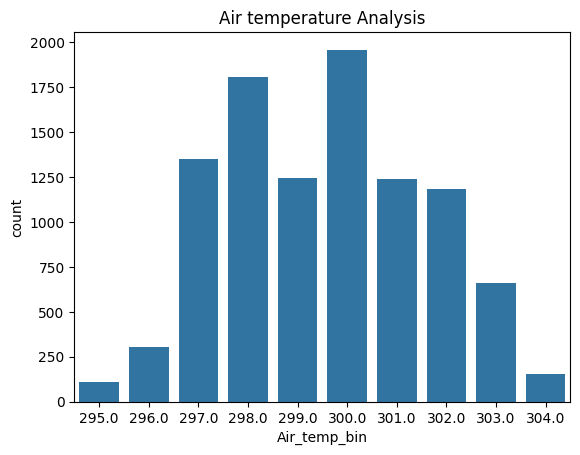

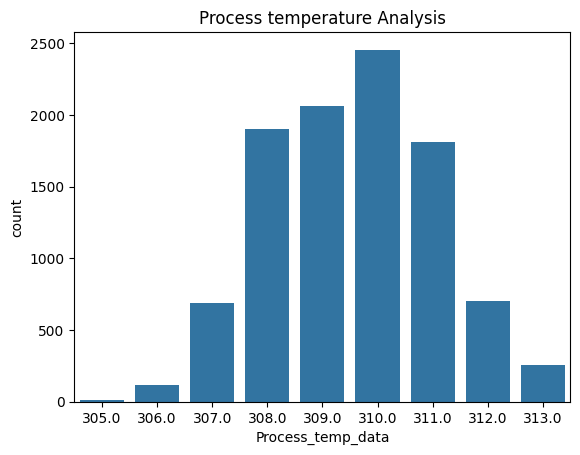

In [ ]:
df["Air_temp_bin"] = (df["Air temperature [K]"] // 1)
df["Process_temp_data"]=(df["Process temperature [K]"]//1)
#In this case which have done floor division by 1 so we do not need multiplication incase we do floor division by any other number we would need it
#2️⃣ // 10 (floor division)

#// means integer (floor) division.

#Each value is divided by 10 and rounded down to the nearest whole number.

#* 10

#Multiply back by 10 to get the lower bound of the bin:
sns.countplot(data=df, x="Air_temp_bin")
df["Air temperature [K]"].describe()
plt.title("Air temperature Analysis")
plt.show()

sns.countplot(data=df, x="Process_temp_data")
df["Process_temp_data"].describe()
plt.title("Process temperature Analysis")
plt.show()


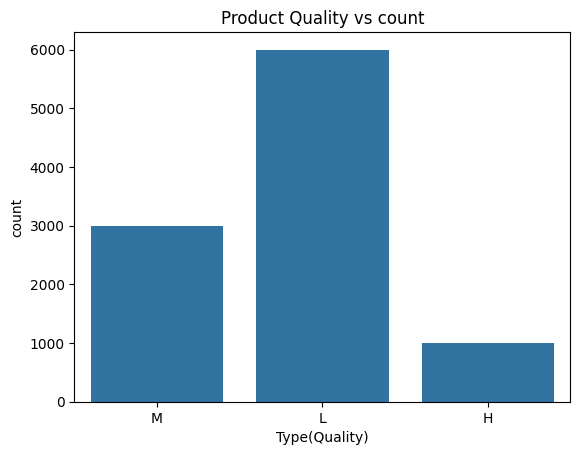

In [ ]:
sns.countplot(data=df, x="Type(Quality)")
plt.title("Product Quality vs count")
plt.show()

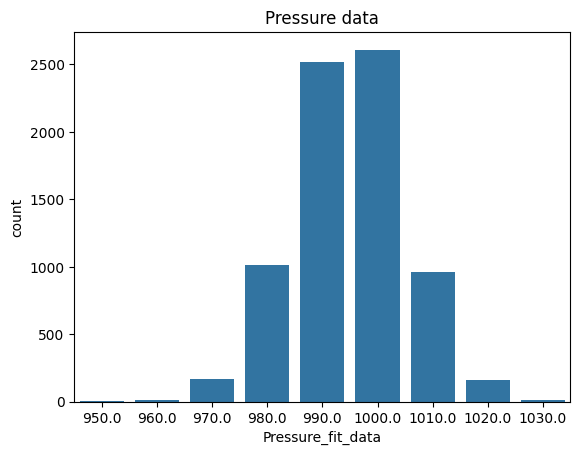

In [ ]:
df["Pressure_fit_data"]=(df["Pressure(Pa)"]//10)*10
sns.countplot(data=df, x="Pressure_fit_data")
df["Pressure(Pa)"].describe()
plt.title("Pressure data")
plt.show()

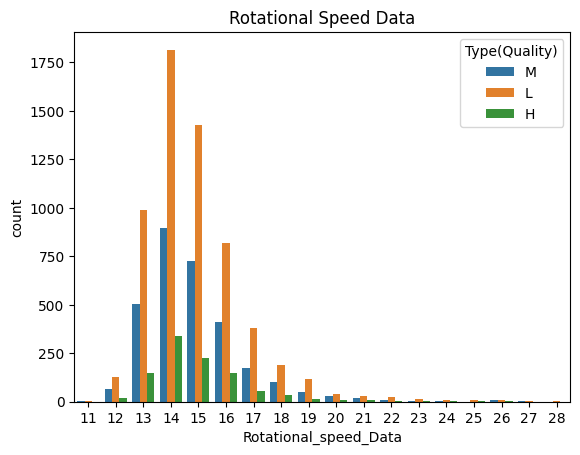

In [ ]:
df["Rotational_speed_Data"]=(df["Rotational speed [rpm]"]//100)

sns.countplot(data=df, x="Rotational_speed_Data", hue="Type(Quality)")

plt.title("Rotational Speed Data")
plt.show()

In [ ]:
df.groupby("Rotational_speed_Data")["Type(Quality)"].describe()

,count,unique,top,freq
Rotational_speed_Data,,,,
11,4,2,M,2
12,207,3,L,126
13,1636,3,L,989
14,3052,3,L,1816
15,2378,3,L,1427
16,1376,3,L,819
17,612,3,L,382
18,324,3,L,189
19,183,3,L,119


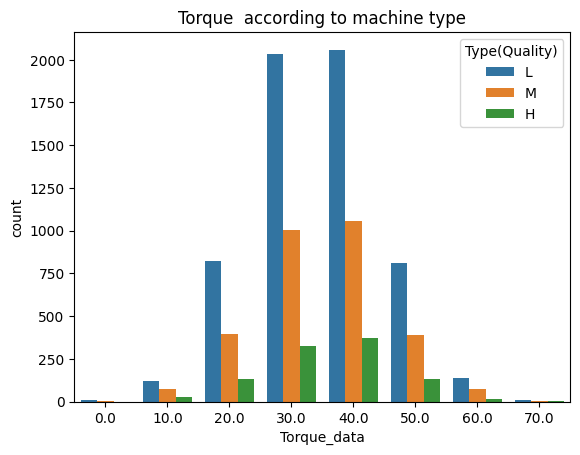

In [ ]:
df["Torque_data"]=(df['Torque [Nm]']//10)*10
sns.countplot(data=df, x="Torque_data", hue="Type(Quality)")
plt.title("Torque  according to machine type")
plt.show()

In [ ]:
df.groupby("Torque_data")["Type(Quality)"].describe()

,count,unique,top,freq
Torque_data,,,,
0.0,11,2,L,8
10.0,217,3,L,118
20.0,1348,3,L,824
30.0,3364,3,L,2034
40.0,3487,3,L,2059
50.0,1334,3,L,810
60.0,225,3,L,139
70.0,14,3,L,8


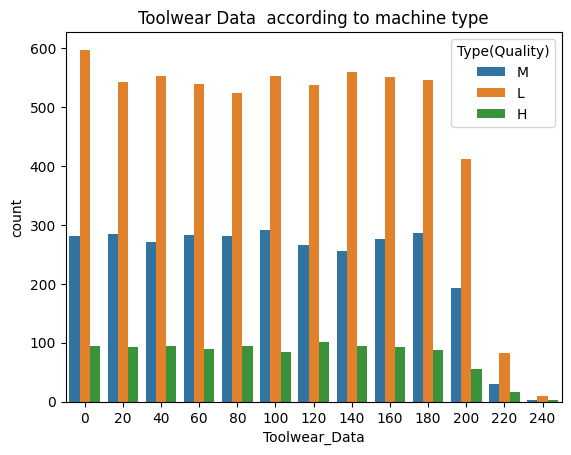

In [ ]:
df["Toolwear_Data"]=(df["Tool wear [min]"]//20)*20
sns.countplot(data=df, x="Toolwear_Data", hue="Type(Quality)")
plt.title("Toolwear Data  according to machine type")
plt.show()

In [ ]:
df.groupby("Toolwear_Data")["Type(Quality)"].describe()

,count,unique,top,freq
Toolwear_Data,,,,
0,973,3,L,597
20,919,3,L,542
40,918,3,L,553
60,910,3,L,538
80,900,3,L,524
100,927,3,L,552
120,904,3,L,537
140,910,3,L,559
160,919,3,L,550


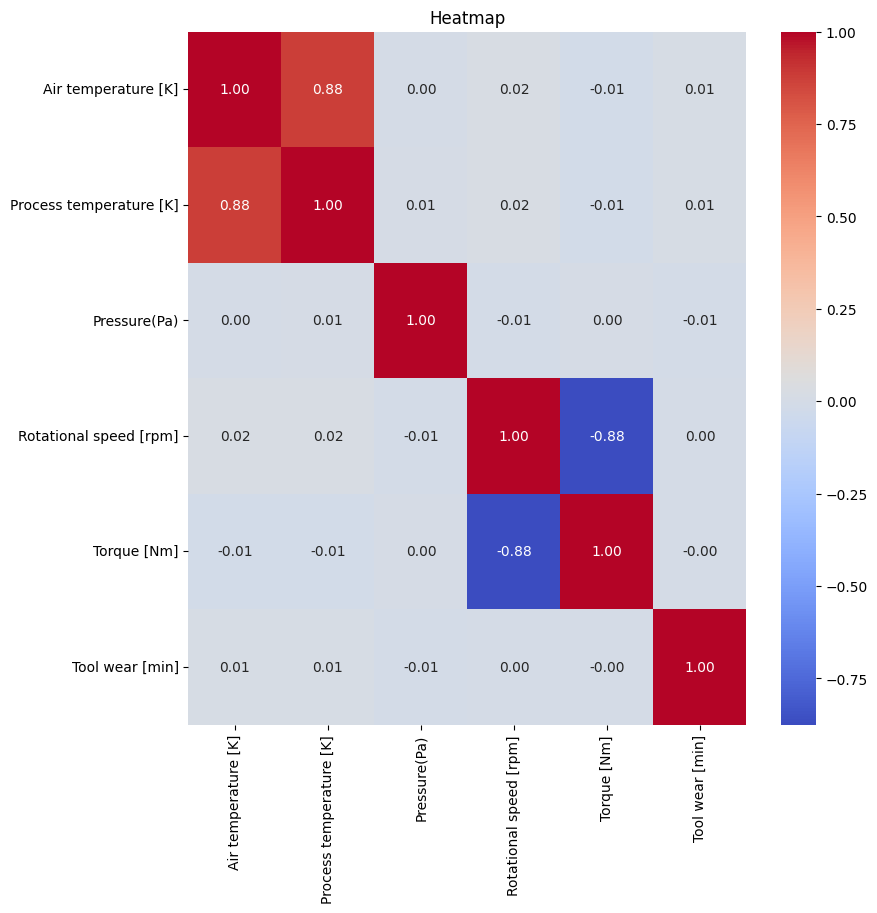

In [ ]:
plt.figure(figsize=(9,9))
numeric_Data=df[['Air temperature [K]','Process temperature [K]','Pressure(Pa)','Rotational speed [rpm]','Torque [Nm]','Tool wear [min]']]
sns.heatmap(numeric_Data.corr(),annot=True,fmt=".2f",cmap="coolwarm")
plt.title("Heatmap")
plt.show()

In [ ]:
input_df=df.drop(columns='Machine failure')
labels_df=df['Machine failure']
print(input_df)


        UDI Product ID Type(Quality)  Air temperature [K]  \
0         1     M14860             M                298.1   
1         2     L47181             L                298.2   
2         3     L47182             L                298.1   
3         4     L47183             L                298.2   
4         5     L47184             L                298.2   
...     ...        ...           ...                  ...   
9995   9996     M24855             M                298.8   
9996   9997     H39410             H                298.9   
9997   9998     M24857             M                299.0   
9998   9999     H39412             H                299.0   
9999  10000     M24859             M                299.0   

      Process temperature [K]  Pressure(Pa)  Rotational speed [rpm]  \
0                       308.6   1000.695430                    1551   
1                       308.7    992.757881                    1408   
2                       308.5   1002.509288           

In [ ]:
input_df_train,input_df_test,labels_df_train,labels_df_test=train_test_split(input_df,labels_df,test_size=0.2,stratify=labels_df)

In [ ]:
Model=LogisticRegression()

In [ ]:
input_df_numeric=input_df_train.drop(columns=["Product ID", "Type(Quality)","Pressure(Pa)"])
Model.fit(input_df_numeric,labels_df_train)

LogisticRegression()

In [ ]:
train_prediction=Model.predict(input_df_numeric)
train_accuracy=accuracy_score(train_prediction,labels_df_train)
print(train_accuracy)

0.971625


In [ ]:
input_df_test_numeric=input_df_test.drop(columns=["Product ID", "Type(Quality)","Pressure(Pa)"])
test_prediction=Model.predict(input_df_test_numeric)
test_accuracy=accuracy_score(test_prediction,labels_df_test)
print(test_accuracy)

0.967


In [ ]:
user_input=(298.9,309.1,1005.342288,2861,4.6,143)
user_input_1=(296.6,307.7,984.2187219,1386,62.3,100)
user_input_array=np.asarray(user_input_1)
user_input_reshape=user_input_array.reshape(1,-1)

prediction=Model.predict(user_input_reshape)
print(prediction)
if prediction==0:
  print("No fail")
else:
  print("fail")

[0]
No fail


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
